# Performance Report

This notebook backfills yearly `_full` IBKR Flex XML archives, refreshes the current-year `_latest` XML, rebuilds `nav_cashflow_history.feather`, previews the latest statement and history tail, and generates the dated performance report with historical `Y<year>` rows appended.


In [23]:
from dataclasses import asdict
from datetime import date, datetime
import os
from pathlib import Path
import sys
import time
import xml.etree.ElementTree as ET

import pandas as pd
from IPython.display import Markdown, display

In [24]:
display(
    pd.Series(
        {
            "python_executable": sys.executable,
            "python_version": sys.version.splitlines()[0],
            "conda_env": os.environ.get("CONDA_DEFAULT_ENV", ""),
            "cwd": str(Path.cwd()),
        },
        name="notebook_runtime",
    )
)

python_executable    /Users/kelvin/opt/anaconda3/envs/py313/bin/python
python_version       3.13.5 | packaged by Anaconda, Inc. | (main, J...
conda_env                                                        py313
cwd                  /Users/kelvin/git_projects/market_helper/noteb...
Name: notebook_runtime, dtype: object

In [ ]:



def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "market_helper").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing 'market_helper'.")


def read_env_file(path: Path) -> dict[str, str]:
    values: dict[str, str] = {}
    if not path.exists():
        return values
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


def local_name(tag: str) -> str:
    return tag.rsplit("}", 1)[-1]


def first_statement(root: ET.Element) -> ET.Element:
    for element in root.iter():
        if local_name(element.tag) == "FlexStatement":
            return element
    raise RuntimeError("Downloaded payload did not include a FlexStatement node.")


def archive_records_to_frame(records) -> pd.DataFrame:
    rows = []
    for record in records:
        payload = asdict(record)
        payload["target_path"] = str(payload["target_path"])
        payload["source_file"] = str(payload["source_file"]) if payload["source_file"] is not None else ""
        payload["xml_from_date"] = payload["xml_from_date"].isoformat() if payload["xml_from_date"] is not None else ""
        payload["xml_to_date"] = payload["xml_to_date"].isoformat() if payload["xml_to_date"] is not None else ""
        payload["error_message"] = payload.get("error_message") or ""
        rows.append(payload)
    return pd.DataFrame(rows)


def run_step(label: str, func, /, *args, **kwargs):
    started_at = datetime.now()
    started_perf = time.perf_counter()
    print(f"{label}:start at={started_at.isoformat(timespec='seconds')}")
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        elapsed_seconds = time.perf_counter() - started_perf
        print(
            f"{label}:error after={elapsed_seconds:.2f}s type={type(exc).__name__} message={exc}"
        )
        raise
    elapsed_seconds = time.perf_counter() - started_perf
    print(f"{label}:done after={elapsed_seconds:.2f}s")
    return result


print("setup:A locate project root")
PROJECT_ROOT = find_project_root(Path.cwd())
print("setup:B project root", PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("setup:C sys.path updated")

print("setup:D import performance analytics")
from market_helper.domain.portfolio_monitor.services.performance_analytics import (
    annualized_return,
    annualized_vol,
    drawdown_plot_frame,
    performance_plot_frame,
    sharpe_ratio,
)
print("setup:E import performance history")
from market_helper.domain.portfolio_monitor.services.nav_cashflow_history import load_nav_cashflow_history
print("setup:F import workflow functions")
from market_helper.workflows.generate_report import (
    backfill_ibkr_flex_full_years,
    generate_ibkr_flex_performance_report,
    rebuild_ibkr_flex_nav_cashflow_history,
    refresh_current_year_latest_flex_xml,
)

CONFIG_ENV_PATH = PROJECT_ROOT / "configs" / "portfolio_monitor" / "local.env"
OUTPUT_DIR = PROJECT_ROOT / "data" / "artifacts" / "portfolio_monitor" / "flex"
RAW_XML_DIR = OUTPUT_DIR / "raw"
HISTORY_PATH = OUTPUT_DIR / "nav_cashflow_history.feather"
RAW_XML_DIR.mkdir(parents=True, exist_ok=True)

ENV_CONFIG = read_env_file(CONFIG_ENV_PATH)

# Optional notebook-local override if you do not want to store the query id in local.env.
FLEX_QUERY_ID_OVERRIDE = ""

FLEX_QUERY_ID = (
    FLEX_QUERY_ID_OVERRIDE.strip()
    or os.environ.get("IBKR_FLEX_QUERY_ID", "").strip()
    or ENV_CONFIG.get("IBKR_FLEX_QUERY_ID", "").strip()
)
FLEX_TOKEN = (
    os.environ.get("IBKR_FLEX_TOKEN", "").strip()
    or ENV_CONFIG.get("IBKR_FLEX_TOKEN", "").strip()
)

ARCHIVE_START_YEAR = 2020
BACKFILL_END_YEAR = 2025
OVERWRITE_FULL_ARCHIVE = False

# IBKR often needs longer than the library defaults for large or historical Flex ranges.
FLEX_POLL_INTERVAL_SECONDS = 10.0
FLEX_MAX_ATTEMPTS = 10

config_series = pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "config_env_path": str(CONFIG_ENV_PATH),
        "raw_xml_dir": str(RAW_XML_DIR),
        "history_path": str(HISTORY_PATH),
        "has_token": bool(FLEX_TOKEN),
        "has_query_id": bool(FLEX_QUERY_ID),
        "archive_start_year": ARCHIVE_START_YEAR,
        "backfill_end_year": BACKFILL_END_YEAR,
        "flex_poll_interval_seconds": FLEX_POLL_INTERVAL_SECONDS,
        "flex_max_attempts": FLEX_MAX_ATTEMPTS,
    },
    name="flex_notebook_config",
)
print("setup:G display config")
display(config_series)


setup:A locate project root
setup:B project root /Users/kelvin/git_projects/market_helper
setup:C sys.path updated
setup:D import performance analytics
setup:E import performance history
setup:F import workflow functions
setup:G display config


project_root                           /Users/kelvin/git_projects/market_helper
config_env_path               /Users/kelvin/git_projects/market_helper/confi...
raw_xml_dir                   /Users/kelvin/git_projects/market_helper/data/...
history_path                  /Users/kelvin/git_projects/market_helper/data/...
has_token                                                                  True
has_query_id                                                               True
archive_start_year                                                         2020
backfill_end_year                                                          2025
flex_poll_interval_seconds                                                 10.0
flex_max_attempts                                                             3
Name: flex_notebook_config, dtype: object

## Historical Full-Year XML Backfill

This cell downloads or promotes yearly `ibkr_flex_<YYYY>_full.xml` archives for every year from `ARCHIVE_START_YEAR` to `BACKFILL_END_YEAR`.


In [28]:
if not FLEX_QUERY_ID:
    raise RuntimeError(
        "Set IBKR_FLEX_QUERY_ID in configs/portfolio_monitor/local.env, your shell env, or FLEX_QUERY_ID_OVERRIDE in the setup cell."
    )
if not FLEX_TOKEN:
    raise RuntimeError("Set IBKR_FLEX_TOKEN in configs/portfolio_monitor/local.env or your shell env.")

full_year_records = run_step(
    "backfill:full-years",
    backfill_ibkr_flex_full_years,
    output_dir=OUTPUT_DIR,
    query_id=FLEX_QUERY_ID,
    token=FLEX_TOKEN,
    start_year=ARCHIVE_START_YEAR,
    end_year=BACKFILL_END_YEAR,
    overwrite_existing=OVERWRITE_FULL_ARCHIVE,
    poll_interval_seconds=FLEX_POLL_INTERVAL_SECONDS,
    max_attempts=FLEX_MAX_ATTEMPTS,
)

full_year_archive_df = (
    archive_records_to_frame(full_year_records)
    .sort_values(["year", "kind"], kind="stable")
    .reset_index(drop=True)
)
full_year_archive_df["target_exists"] = full_year_archive_df["target_path"].map(lambda raw: Path(raw).exists())

display(
    full_year_archive_df.loc[
        :,
        [
            "year",
            "kind",
            "status",
            "target_exists",
            "target_path",
            "source_file",
            "xml_from_date",
            "xml_to_date",
            "error_message",
        ],
    ]
)

display(
    pd.DataFrame(
        {
            "full_xml_file": [path.name for path in sorted(RAW_XML_DIR.glob("ibkr_flex_*_full.xml"))],
        }
    )
)


backfill:full-years:start at=2026-04-12T17:38:43
backfill:full-years:done after=11.41s


,year,kind,status,target_exists,target_path,source_file,xml_from_date,xml_to_date,error_message
0,2020,full,skipped,True,/Users/kelvin/git_projects/market_helper/data/...,,,,
1,2021,full,skipped,True,/Users/kelvin/git_projects/market_helper/data/...,,,,
2,2022,full,downloaded,True,/Users/kelvin/git_projects/market_helper/data/...,,2022-01-03,2022-12-30,
3,2023,full,skipped,True,/Users/kelvin/git_projects/market_helper/data/...,,,,
4,2024,full,skipped,True,/Users/kelvin/git_projects/market_helper/data/...,,,,
5,2025,full,skipped,True,/Users/kelvin/git_projects/market_helper/data/...,,,,


,full_xml_file
0,ibkr_flex_2020_full.xml
1,ibkr_flex_2021_full.xml
2,ibkr_flex_2022_full.xml
3,ibkr_flex_2023_full.xml
4,ibkr_flex_2024_full.xml
5,ibkr_flex_2025_full.xml


## Current-Year Latest XML Refresh

This cell refreshes the rolling `ibkr_flex_<current_year>_latest.xml` archive for the current year YTD range.


In [6]:
print(
    f"refresh:params poll_interval={FLEX_POLL_INTERVAL_SECONDS}s max_attempts={FLEX_MAX_ATTEMPTS}"
)
latest_record = run_step(
    "refresh:latest-xml",
    refresh_current_year_latest_flex_xml,
    output_dir=OUTPUT_DIR,
    query_id=FLEX_QUERY_ID,
    token=FLEX_TOKEN,
    poll_interval_seconds=FLEX_POLL_INTERVAL_SECONDS,
    max_attempts=FLEX_MAX_ATTEMPTS,
)
print(
    f"refresh:result status={latest_record.status} xml_from={latest_record.xml_from_date} xml_to={latest_record.xml_to_date} path={latest_record.target_path}"
)
display(archive_records_to_frame([latest_record]))


refresh:params poll_interval=10.0s max_attempts=3
refresh:latest-xml:start at=2026-04-12T14:22:43
refresh:latest-xml:done after=11.48s
refresh:result status=refreshed xml_from=2026-01-01 xml_to=2026-04-10 path=/Users/kelvin/git_projects/market_helper/data/artifacts/portfolio_monitor/flex/raw/ibkr_flex_2026_latest.xml


,year,kind,target_path,status,error_message,source_file,xml_from_date,xml_to_date
0,2026,latest,/Users/kelvin/git_projects/market_helper/data/...,refreshed,,,2026-01-01,2026-04-10


## Rebuild Feather History

This cell rebuilds `nav_cashflow_history.feather` from the archived `_full` files plus the current `_latest` file.


In [7]:
history_path = run_step(
    "history:rebuild-feather",
    rebuild_ibkr_flex_nav_cashflow_history,
    output_dir=OUTPUT_DIR,
    extra_xml_paths=[latest_record.target_path],
)
display(
    pd.DataFrame(
        [
            {
                "history_path": str(history_path),
                "exists": history_path.exists(),
                "size_bytes": history_path.stat().st_size if history_path.exists() else None,
            }
        ]
    )
)


history:rebuild-feather:start at=2026-04-12T14:22:54
history:rebuild-feather:done after=3.44s


,history_path,exists,size_bytes
0,/Users/kelvin/git_projects/market_helper/data/...,True,60626


In [8]:
latest_xml_text = latest_record.target_path.read_text(encoding="utf-8")
latest_root = ET.fromstring(latest_xml_text)
latest_statement = first_statement(latest_root)
latest_lines = latest_xml_text.splitlines()
latest_preview = "\n".join(latest_lines[:60])

latest_summary_df = pd.DataFrame(
    [
        {
            "saved_xml_path": str(latest_record.target_path),
            "statement_from_date": latest_statement.get("fromDate", ""),
            "statement_to_date": latest_statement.get("toDate", ""),
            "statement_period": latest_statement.get("period", ""),
            "when_generated": latest_statement.get("whenGenerated", ""),
            "account_id": latest_statement.get("accountId", ""),
            "preview_lines": min(60, len(latest_lines)),
        }
    ]
)

display(latest_summary_df)
display(Markdown("```xml\n" + latest_preview + "\n```"))


,saved_xml_path,statement_from_date,statement_to_date,statement_period,when_generated,account_id,preview_lines
0,/Users/kelvin/git_projects/market_helper/data/...,20260101,20260410,,20260412;022244,U2935967,60


```xml
<FlexQueryResponse queryName="perf_report" type="AF">
<FlexStatements count="1">
<FlexStatement accountId="U2935967" fromDate="20260101" toDate="20260410" period="" whenGenerated="20260412;022244">
<EquitySummaryInBase>
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20251231" cash="-2966.466434281" cashLong="99196.344405447" cashShort="-102162.810839728" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-102162.810839728" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="87241.0398" slbCashCollateralLong="87241.0398" slbCashCollateralShort="0" stock="899341.19634" stockLong="899341.19634" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-87241.0398" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-87241.0398" options="-2722.2691" optionsLong="0" optionsShort="-2722.2691" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.60824" dividendAccrualsLong="448.60824" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-246.70005" interestAccrualsLong="4.12806" interestAccrualsShort="-250.82811" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="893854.368995719" totalLong="1086231.316845447" totalShort="-192376.947849728" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260101" cash="-2966.463957443" cashLong="99195.568000118" cashShort="-102162.031957561" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-102162.031957561" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="86900.164" slbCashCollateralLong="86900.164" slbCashCollateralShort="0" stock="899341.19634" stockLong="899341.19634" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-86900.164" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-86900.164" options="-2722.2691" optionsLong="0" optionsShort="-2722.2691" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.60824" dividendAccrualsLong="448.60824" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-246.699411" interestAccrualsLong="4.12806" interestAccrualsShort="-250.827471" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="893854.372111557" totalLong="1085889.664640117" totalShort="-192035.292528561" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260102" cash="-6042.151654254" cashLong="96954.541283391" cashShort="-102996.692937645" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-102996.692937645" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="99607.13" slbCashCollateralLong="99607.13" slbCashCollateralShort="0" stock="907353.293044" stockLong="907353.293044" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-99607.13" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-99607.13" options="-2672.558373" optionsLong="0" optionsShort="-2672.558373" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.712892" dividendAccrualsLong="448.712892" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-263.0245404" interestAccrualsLong="4.412009" interestAccrualsShort="-267.4365494" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="898824.271368347" totalLong="1104368.089228391" totalShort="-205543.817860045" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260105" cash="4554.003847823" cashLong="101106.352865932" cashShort="-96552.349018109" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-96552.349018109" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="81833.1197" slbCashCollateralLong="81833.1197" slbCashCollateralShort="0" stock="908482.346592" stockLong="908482.346592" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-81833.1197" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-81833.1197" options="-2826.6498" optionsLong="0" optionsShort="-2826.6498" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="447.491952" dividendAccrualsLong="447.491952" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-287.4251798" interestAccrualsLong="5.990676" interestAccrualsShort="-293.4158558" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="910369.767412023" totalLong="1091875.301785932" totalShort="-181505.534373909" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260106" cash="843.922224927" cashLong="99555.992892993" cashShort="-98712.070668065" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-98712.070668065" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="5118.372" slbCashCollateralLong="5118.372" slbCashCollateralShort="0" stock="912902.34648" stockLong="912902.34648" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-5118.372" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-5118.372" options="-2964.345686" optionsLong="0" optionsShort="-2964.345686" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="446.724504" dividendAccrualsLong="446.724504" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-39.551712" interestAccrualsLong="1.587944" interestAccrualsShort="-41.139656" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="911189.095810927" totalLong="1018025.023820993" totalShort="-106835.928010065" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260107" cash="2982.941652297" cashLong="101537.366870182" cashShort="-98554.425217885" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-98554.425217885" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="0" slbCashCollateralLong="0" slbCashCollateralShort="0" stock="909748.448392" stockLong="909748.448392" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="0" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="0" options="-2928.3604" optionsLong="0" optionsShort="-2928.3604" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="447.352416" dividendAccrualsLong="447.352416" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-47.280923" interestAccrualsLong="1.590176" interestAccrualsShort="-48.871099" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="910203.101137297" totalLong="1011734.757854182" totalShort="-101531.656716885" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260108" cash="-2429.752178977" cashLong="96262.316091011" cashShort="-98692.068269989" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-98692.068269989" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="2446.8192" slbCashCollateralLong="2446.8192" slbCashCollateralShort="0" stock="912449.78624" stockLong="912449.78624" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-2446.8192" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-2446.8192" options="-2859.257543" optionsLong="0" optionsShort="-2859.257543" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.294284" dividendAccrualsLong="448.294284" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-55.849275" interestAccrualsLong="1.593524" interestAccrualsShort="-57.442799" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="907553.221527023" totalLong="1011608.809339011" totalShort="-104055.587811989" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260109" cash="1375.307956719" cashLong="94257.149842841" cashShort="-92881.841886122" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-92881.841886122" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="18353.7982" slbCashCollateralLong="18353.7982" slbCashCollateralShort="0" stock="913607.4765" stockLong="913607.4765" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-18353.7982" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-18353.7982" options="-2942.568375" optionsLong="0" optionsShort="-2942.568375" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="449.1315" dividendAccrualsLong="449.1315" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-63.661462" interestAccrualsLong="1.5965" interestAccrualsShort="-65.257962" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="912425.686119719" totalLong="1026669.152542841" totalShort="-114243.466423122" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260112" cash="3006.751488178" cashLong="96379.855544525" cashShort="-93373.104056346" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-93373.104056346" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="0" slbCashCollateralLong="0" slbCashCollateralShort="0" stock="921514.401269" stockLong="921514.401269" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="0" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="0" options="-2973.373711" optionsLong="0" optionsShort="-2973.373711" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.573356" dividendAccrualsLong="448.573356" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-89.289717" interestAccrualsLong="1.594516" interestAccrualsShort="-90.884233" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="921907.062685178" totalLong="1018344.424685525" totalShort="-96437.362000346" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260113" cash="410.908929026" cashLong="94428.041631294" cashShort="-94017.132702268" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-94017.132702268" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="9547.8075" slbCashCollateralLong="9547.8075" slbCashCollateralShort="0" stock="920075.007375" stockLong="920075.007375" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-9547.8075" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-9547.8075" options="-2991.729495" optionsLong="0" optionsShort="-2991.729495" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="449.48034" dividendAccrualsLong="449.48034" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-96.488029" interestAccrualsLong="1.59774" interestAccrualsShort="-98.085769" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="917847.179120026" totalLong="1024501.934586294" totalShort="-106654.755466268" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260114" cash="2194.757436862" cashLong="96182.740758271" cashShort="-93987.983321409" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-93987.983321409" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="10436.85" slbCashCollateralLong="10436.85" slbCashCollateralShort="0" stock="919030.577634" stockLong="919030.577634" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-10436.85" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-10436.85" options="-2868.79725" optionsLong="0" optionsShort="-2868.79725" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="449.271036" dividendAccrualsLong="449.271036" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-103.280709" interestAccrualsLong="1.596996" interestAccrualsShort="-104.877705" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="918702.528147862" totalLong="1026101.036424271" totalShort="-107398.508276409" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260115" cash="-1252.790422236" cashLong="92752.422075261" cashShort="-94005.212497497" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-94005.212497497" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="6181.92" slbCashCollateralLong="6181.92" slbCashCollateralShort="0" stock="918871.326043" stockLong="918871.326043" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-6181.92" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-6181.92" options="-2843.107201" optionsLong="0" optionsShort="-2843.107201" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="449.340804" dividendAccrualsLong="449.340804" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-111.691311" interestAccrualsLong="1.597244" interestAccrualsShort="-113.288555" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="915113.077912764" totalLong="1018256.606166261" totalShort="-103143.528253497" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260116" cash="-1847.445527707" cashLong="87018.049617997" cashShort="-88865.495145705" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-88865.495145705" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="95641.425" slbCashCollateralLong="95641.425" slbCashCollateralShort="0" stock="912258.06638" stockLong="912258.06638" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-95641.425" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-95641.425" options="-2827.53751" optionsLong="0" optionsShort="-2827.53751" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="449.65476" dividendAccrualsLong="449.65476" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-119.798597" interestAccrualsLong="1.59836" interestAccrualsShort="-121.396957" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="907912.939505293" totalLong="1095368.794117997" totalShort="-187455.854612705" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260119" cash="-1373.070189348" cashLong="87311.960340918" cashShort="-88685.030530266" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-88685.030530266" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="95708.25" slbCashCollateralLong="95708.25" slbCashCollateralShort="0" stock="909285.619616" stockLong="909285.619616" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-95708.25" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-95708.25" options="-2818.324432" optionsLong="0" optionsShort="-2818.324432" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.189632" dividendAccrualsLong="448.189632" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-119.458684" interestAccrualsLong="1.593152" interestAccrualsShort="-121.051836" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="905422.955942653" totalLong="1092755.612740919" totalShort="-187332.656798266" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260120" cash="-207.69289603" cashLong="91216.923748009" cashShort="-91424.616644038" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-91424.616644038" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="85278.6" slbCashCollateralLong="85278.6" slbCashCollateralShort="0" stock="898093.235069" stockLong="898093.235069" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-85278.6" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-85278.6" options="-1535.000299" optionsLong="0" optionsShort="-1535.000299" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="447.945444" dividendAccrualsLong="447.945444" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-151.097741" interestAccrualsLong="3.300137" interestAccrualsShort="-154.397878" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="896647.38957697" totalLong="1075040.004398009" totalShort="-178392.614821038" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260121" cash="3261.344371557" cashLong="92741.760597565" cashShort="-89480.416226008" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-89480.416226008" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="107661.5122" slbCashCollateralLong="107661.5122" slbCashCollateralShort="0" stock="962878.648458" stockLong="962878.648458" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-107661.5122" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-107661.5122" options="-1241.193366" optionsLong="0" optionsShort="-1241.193366" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="448.119864" dividendAccrualsLong="448.119864" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-158.466489" interestAccrualsLong="3.301422" interestAccrualsShort="-161.767911" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="965188.452838557" totalLong="1163733.342541565" totalShort="-198544.889703008" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260122" cash="4227.571049272" cashLong="97212.675715316" cashShort="-92985.104666044" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-92985.104666044" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="200348.7852" slbCashCollateralLong="200348.7852" slbCashCollateralShort="0" stock="969741.37743" stockLong="969741.37743" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-200348.7852" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-200348.7852" options="-1144.24044" optionsLong="0" optionsShort="-1144.24044" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="446.86404" dividendAccrualsLong="446.86404" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-158.121786" interestAccrualsLong="3.29217" interestAccrualsShort="-161.413956" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="973113.450293272" totalLong="1267752.994555316" totalShort="-294639.544262044" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260123" cash="3515.042577412" cashLong="103383.905571692" cashShort="-99868.86299428" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-99868.86299428" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="122454.633" slbCashCollateralLong="122454.633" slbCashCollateralShort="0" stock="973047.3732" stockLong="973047.3732" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-122454.633" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-122454.633" options="-1153.41144" optionsLong="0" optionsShort="-1153.41144" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="443.72448" dividendAccrualsLong="443.72448" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-165.105492" interestAccrualsLong="5.35512" interestAccrualsShort="-170.460612" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="975687.623325411" totalLong="1199334.991371692" totalShort="-223647.36804628" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260126" cash="5230.443449594" cashLong="109351.113292273" cashShort="-104120.669842679" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-104120.669842679" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="104599.104" slbCashCollateralLong="104599.104" slbCashCollateralShort="0" stock="979196.4491" stockLong="979196.4491" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-104599.104" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-104599.104" options="-1115.43145" optionsLong="0" optionsShort="-1115.43145" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="442.922148" dividendAccrualsLong="442.922148" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-189.373762" interestAccrualsLong="5.345437" interestAccrualsShort="-194.719199" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="983565.009485594" totalLong="1193594.933977273" totalShort="-210029.924491679" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260127" cash="4442.426208719" cashLong="115786.216074512" cashShort="-111343.789865794" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-111343.789865794" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="94181.2672" slbCashCollateralLong="94181.2672" slbCashCollateralShort="0" stock="987423.65514" stockLong="987423.65514" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-94181.2672" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-94181.2672" options="-1097.375058" optionsLong="0" optionsShort="-1097.375058" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="439.433748" dividendAccrualsLong="439.433748" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-193.876071" interestAccrualsLong="6.714201" interestAccrualsShort="-200.590272" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="991014.263967719" totalLong="1197837.286363512" totalShort="-206823.022395794" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260128" cash="4192.683401835" cashLong="115316.995543351" cashShort="-111124.312141517" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-111124.312141517" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="88558.1697" slbCashCollateralLong="88558.1697" slbCashCollateralShort="0" stock="991691.723555" stockLong="991691.723555" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-88558.1697" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-88558.1697" options="-1109.321863" optionsLong="0" optionsShort="-1109.321863" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="440.340732" dividendAccrualsLong="440.340732" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-202.487931" interestAccrualsLong="6.728059" interestAccrualsShort="-209.21599" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="995012.937894835" totalLong="1196013.957589352" totalShort="-201001.019694517" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260129" cash="833.771151066" cashLong="119279.443283074" cashShort="-118445.672132009" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-118445.672132009" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="80201.4928" slbCashCollateralLong="80201.4928" slbCashCollateralShort="0" stock="1002035.47374" stockLong="1002035.47374" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-80201.4928" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-80201.4928" options="-1127.187945" optionsLong="0" optionsShort="-1127.187945" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="441.10818" dividendAccrualsLong="441.10818" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-209.853226" interestAccrualsLong="6.739785" interestAccrualsShort="-216.593011" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1001973.311900065" totalLong="1201964.257788074" totalShort="-199990.945888009" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260130" cash="-253.813218236" cashLong="113148.312484073" cashShort="-113402.125702308" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-113402.125702308" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="93939.705" slbCashCollateralLong="93939.705" slbCashCollateralShort="0" stock="990663.703292" stockLong="990663.703292" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-93939.705" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-93939.705" options="-1186.907444" optionsLong="0" optionsShort="-1186.907444" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-221.271367" interestAccrualsLong="6.781892" interestAccrualsShort="-228.053259" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="989001.711262764" totalLong="1197758.502668072" totalShort="-208756.791405308" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260202" cash="7504.154080138" cashLong="107785.050660376" cashShort="-100280.896580238" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-100280.896580238" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="82873.9568" slbCashCollateralLong="82873.9568" slbCashCollateralShort="0" stock="977667.549656" stockLong="977667.549656" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-82873.9568" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-82873.9568" options="-1073.422088" optionsLong="0" optionsShort="-1073.422088" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="326.930456" dividendAccrualsLong="326.930456" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-245.3308887" interestAccrualsLong="8.2706" interestAccrualsShort="-253.6014887" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="984179.881215438" totalLong="1168661.758172376" totalShort="-184481.876956938" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260203" cash="3817.284057322" cashLong="111301.928180997" cashShort="-107484.644123674" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-107484.644123674" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="79947.4368" slbCashCollateralLong="79947.4368" slbCashCollateralShort="0" stock="983470.728" stockLong="983470.728" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-79947.4368" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-79947.4368" options="-1157.8082" optionsLong="0" optionsShort="-1157.8082" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="326.3138" dividendAccrualsLong="326.3138" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-254.5335138" interestAccrualsLong="8.255" interestAccrualsShort="-262.7885138" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="986201.984143522" totalLong="1175054.661780996" totalShort="-188852.677637474" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260204" cash="2716.287460638" cashLong="110803.850821326" cashShort="-108087.563360688" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-108087.563360688" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="98474.53" slbCashCollateralLong="98474.53" slbCashCollateralShort="0" stock="979611.299982" stockLong="979611.299982" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-98474.53" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-98474.53" options="-1218.565404" optionsLong="0" optionsShort="-1218.565404" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="326.981844" dividendAccrualsLong="326.981844" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-24.437924" interestAccrualsLong="0" interestAccrualsShort="-24.437924" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="981411.565958638" totalLong="1189216.662647326" totalShort="-207805.096688688" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260205" cash="4716.248223741" cashLong="112034.287234635" cashShort="-107318.039010894" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-107318.039010894" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="97010.298" slbCashCollateralLong="97010.298" slbCashCollateralShort="0" stock="971811.257844" stockLong="971811.257844" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-97010.298" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-97010.298" options="-1400.146874" optionsLong="0" optionsShort="-1400.146874" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-32.78327" interestAccrualsLong="2.091656" interestAccrualsShort="-34.874926" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="975094.575923741" totalLong="1180857.934734635" totalShort="-205763.358810894" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260206" cash="8694.183088327" cashLong="115691.476634243" cashShort="-106997.293545916" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-106997.293545916" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="97802.7736" slbCashCollateralLong="97802.7736" slbCashCollateralShort="0" stock="986028.881936" stockLong="986028.881936" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-97802.7736" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-97802.7736" options="-1107.075368" optionsLong="0" optionsShort="-1107.075368" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-39.549029" interestAccrualsLong="2.084768" interestAccrualsShort="-41.633797" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="993576.440627327" totalLong="1199525.216938243" totalShort="-205948.776310916" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260209" cash="2328.377373979" cashLong="124782.345718065" cashShort="-122453.968344086" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-122453.968344086" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="99742.1656" slbCashCollateralLong="99742.1656" slbCashCollateralShort="0" stock="1004607.153668" stockLong="1004607.153668" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-99742.1656" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-99742.1656" options="-1040.70925" optionsLong="0" optionsShort="-1040.70925" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-62.06662" interestAccrualsLong="5.263648" interestAccrualsShort="-67.330268" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1005832.755171979" totalLong="1229136.928634065" totalShort="-223304.173462086" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260210" cash="4174.068755565" cashLong="126133.324576438" cashShort="-121959.255820874" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-121959.255820874" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="102572.8098" slbCashCollateralLong="102572.8098" slbCashCollateralShort="0" stock="1002530.717856" stockLong="1002530.717856" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-102572.8098" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-102572.8098" options="-1081.998456" optionsLong="0" optionsShort="-1081.998456" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-68.66589" interestAccrualsLong="5.261568" interestAccrualsShort="-73.927458" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1005554.122265565" totalLong="1231242.113800438" totalShort="-225687.991534874" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260211" cash="-1832.640720102" cashLong="124925.818689079" cashShort="-126758.459409181" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-126758.459409181" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="87506.4528" slbCashCollateralLong="87506.4528" slbCashCollateralShort="0" stock="1008221.251726" stockLong="1008221.251726" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-87506.4528" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-87506.4528" options="-1063.48775" optionsLong="0" optionsShort="-1063.48775" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-76.183916" interestAccrualsLong="6.993142" interestAccrualsShort="-83.177058" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1005248.939339898" totalLong="1220660.516357079" totalShort="-215411.577017181" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260212" cash="206.203653038" cashLong="126979.730601765" cashShort="-126773.526948727" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-126773.526948727" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="86742.7314" slbCashCollateralLong="86742.7314" slbCashCollateralShort="0" stock="996120.54378" stockLong="996120.54378" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-86742.7314" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-86742.7314" options="-1277.334693" optionsLong="0" optionsShort="-1277.334693" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-83.79322" interestAccrualsLong="6.995358" interestAccrualsShort="-90.788578" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="994965.619520038" totalLong="1209850.001139765" totalShort="-214884.381619727" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260213" cash="3288.454805481" cashLong="130023.686090372" cashShort="-126735.231284891" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-126735.231284891" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="78462.9153" slbCashCollateralLong="78462.9153" slbCashCollateralShort="0" stock="999127.503673" stockLong="999127.503673" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-78462.9153" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-78462.9153" options="-1281.726797" optionsLong="0" optionsShort="-1281.726797" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-93.398478" interestAccrualsLong="8.419541" interestAccrualsShort="-101.818019" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1001040.833203481" totalLong="1207622.524604372" totalShort="-206581.691400891" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260216" cash="3405.072895037" cashLong="130143.450634435" cashShort="-126738.377739399" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-126738.377739399" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="78146.4684" slbCashCollateralLong="78146.4684" slbCashCollateralShort="0" stock="999206.655024" stockLong="999206.655024" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-78146.4684" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-78146.4684" options="-1281.828336" optionsLong="0" optionsShort="-1281.828336" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-93.384969" interestAccrualsLong="8.420208" interestAccrualsShort="-101.805177" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1001236.514614037" totalLong="1207504.994266436" totalShort="-206268.479652399" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260217" cash="2732.566623969" cashLong="129516.393453122" cashShort="-126783.826829153" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-126783.826829153" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="77277.816" slbCashCollateralLong="77277.816" slbCashCollateralShort="0" stock="997502.474288" stockLong="997502.474288" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-77277.816" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-77277.816" options="-1192.1776" optionsLong="0" optionsShort="-1192.1776" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-126.11091" interestAccrualsLong="10.999859" interestAccrualsShort="-137.110769" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="998916.75240197" totalLong="1204307.683600122" totalShort="-205390.931198153" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260218" cash="3877.413645934" cashLong="123627.347791711" cashShort="-119749.934145776" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-119749.934145776" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="80578.0716" slbCashCollateralLong="80578.0716" slbCashCollateralShort="0" stock="998303.670144" stockLong="998303.670144" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-80578.0716" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-80578.0716" options="-1141.544448" optionsLong="0" optionsShort="-1141.544448" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-133.8939" interestAccrualsLong="11.037312" interestAccrualsShort="-144.931212" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1000905.645441934" totalLong="1202520.126847711" totalShort="-201614.481405776" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260219" cash="2797.073561654" cashLong="122622.41837583" cashShort="-119825.344814176" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-119825.344814176" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="81346.6368" slbCashCollateralLong="81346.6368" slbCashCollateralShort="0" stock="997775.296908" stockLong="997775.296908" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-81346.6368" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-81346.6368" options="-1190.002788" optionsLong="0" optionsShort="-1190.002788" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-140.260168" interestAccrualsLong="12.352268" interestAccrualsShort="-152.612436" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="999242.107513654" totalLong="1201756.70435183" totalShort="-202514.596838176" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260220" cash="1157.373428145" cashLong="124957.225539388" cashShort="-123799.852111243" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-123799.852111243" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="92291.9868" slbCashCollateralLong="92291.9868" slbCashCollateralShort="0" stock="1008514.960296" stockLong="1008514.960296" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-92291.9868" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-92291.9868" options="-1096.060696" optionsLong="0" optionsShort="-1096.060696" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-149.92945" interestAccrualsLong="12.338632" interestAccrualsShort="-162.268082" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1008426.343578145" totalLong="1225776.511267387" totalShort="-217350.167689243" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260223" cash="4446.760889732" cashLong="128220.428088288" cashShort="-123773.667198556" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-123773.667198556" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="89754.0468" slbCashCollateralLong="89754.0468" slbCashCollateralShort="0" stock="1004184.507402" stockLong="1004184.507402" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-89754.0468" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-89754.0468" options="-1213.985436" optionsLong="0" optionsShort="-1213.985436" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-170.71386" interestAccrualsLong="15.566514" interestAccrualsShort="-186.280374" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1007246.568995732" totalLong="1222174.548804288" totalShort="-214927.979808556" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260224" cash="6403.28267952" cashLong="127257.884835235" cashShort="-120854.602155715" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-120854.602155715" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="80137.782" slbCashCollateralLong="80137.782" slbCashCollateralShort="0" stock="1005488.638436" stockLong="1005488.638436" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-80137.782" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-80137.782" options="-1090.7148" optionsLong="0" optionsShort="-1090.7148" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-179.023204" interestAccrualsLong="15.568972" interestAccrualsShort="-194.592176" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1010622.18311152" totalLong="1212899.874243234" totalShort="-202277.691131715" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260225" cash="22720.695569989" cashLong="130144.443971799" cashShort="-107423.74840181" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-107423.74840181" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="41880.408" slbCashCollateralLong="41880.408" slbCashCollateralShort="0" stock="995928.844716" stockLong="995928.844716" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-41880.408" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-41880.408" options="-988.969176" optionsLong="0" optionsShort="-988.969176" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-183.191372" interestAccrualsLong="17.6904" interestAccrualsShort="-200.881772" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1017477.379737989" totalLong="1167971.387087799" totalShort="-150494.00734981" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260226" cash="4300.249500019" cashLong="130511.769259032" cashShort="-126211.519759013" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-126211.519759013" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="83253.5496" slbCashCollateralLong="83253.5496" slbCashCollateralShort="0" stock="1011812.86304" stockLong="1011812.86304" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-83253.5496" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-83253.5496" options="-1032.4352" optionsLong="0" optionsShort="-1032.4352" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-188.499488" interestAccrualsLong="17.696" interestAccrualsShort="-206.195488" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1014892.17785202" totalLong="1225595.877899032" totalShort="-210703.700047013" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260227" cash="7654.851305481" cashLong="136382.798309978" cashShort="-128727.947004498" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-128727.947004498" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="194329.888" slbCashCollateralLong="194329.888" slbCashCollateralShort="0" stock="1013529.29645" stockLong="1013529.29645" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-194329.888" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-194329.888" options="-1098.02" optionsLong="0" optionsShort="-1098.02" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-189.996018" interestAccrualsLong="17.71" interestAccrualsShort="-207.706018" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1019896.131737481" totalLong="1344259.692759978" totalShort="-324363.561022498" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260302" cash="1668.701612312" cashLong="124821.969158459" cashShort="-123153.267546147" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-123153.267546147" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="130494.87" slbCashCollateralLong="130494.87" slbCashCollateralShort="0" stock="1008425.057626" stockLong="1008425.057626" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-130494.87" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-130494.87" options="-2254.5547" optionsLong="0" optionsShort="-2254.5547" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="341.245732" dividendAccrualsLong="341.245732" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-183.6689304" interestAccrualsLong="25.799084" interestAccrualsShort="-209.4680144" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="1007996.781339913" totalLong="1264108.94160046" totalShort="-256112.160260547" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260303" cash="-1365.799217903" cashLong="114366.516283291" cashShort="-115732.315501194" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-115732.315501194" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="116829.3564" slbCashCollateralLong="116829.3564" slbCashCollateralShort="0" stock="983338.698125" stockLong="983338.698125" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-116829.3564" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-116829.3564" options="-2566.4975" optionsLong="0" optionsShort="-2566.4975" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="342.34445" dividendAccrualsLong="342.34445" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-184.1418238" interestAccrualsLong="25.88215" interestAccrualsShort="-210.0239738" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="979564.604033297" totalLong="1214902.797408291" totalShort="-235338.193374994" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260304" cash="539.564631768" cashLong="116351.357124235" cashShort="-115811.792492467" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-115811.792492467" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="126472.5" slbCashCollateralLong="126472.5" slbCashCollateralShort="0" stock="990797.366925" stockLong="990797.366925" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-126472.5" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-126472.5" options="-2237.86475" optionsLong="0" optionsShort="-2237.86475" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="341.80849" dividendAccrualsLong="341.80849" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="4.54078" interestAccrualsLong="4.54078" interestAccrualsShort="0" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="989445.416076768" totalLong="1233967.573319235" totalShort="-244522.157242467" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260305" cash="3123.394066888" cashLong="101129.662551667" cashShort="-98006.268484779" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-98006.268484779" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="92188.038" slbCashCollateralLong="92188.038" slbCashCollateralShort="0" stock="963857.77832" stockLong="963857.77832" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-92188.038" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-92188.038" options="-2502.8242" optionsLong="0" optionsShort="-2502.8242" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-0.113272" interestAccrualsLong="4.561072" interestAccrualsShort="-4.674344" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="964478.234914889" totalLong="1157180.039943667" totalShort="-192701.805028779" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260306" cash="-605.044733026" cashLong="106669.391349861" cashShort="-107274.436082887" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-107274.436082887" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="59647.5472" slbCashCollateralLong="59647.5472" slbCashCollateralShort="0" stock="965813.422704" stockLong="965813.422704" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-59647.5472" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-59647.5472" options="-3324.6408" optionsLong="0" optionsShort="-3324.6408" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-4.130662" interestAccrualsLong="6.52392" interestAccrualsShort="-10.654582" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="961879.606508974" totalLong="1132136.885173861" totalShort="-170257.278664887" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260309" cash="-3993.888564076" cashLong="102876.883318636" cashShort="-106870.771882711" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-106870.771882711" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="75021.2424" slbCashCollateralLong="75021.2424" slbCashCollateralShort="0" stock="969800.937994" stockLong="969800.937994" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-75021.2424" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-75021.2424" options="-2684.3076" optionsLong="0" optionsShort="-2684.3076" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-20.507228" interestAccrualsLong="8.641788" interestAccrualsShort="-29.149016" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="963102.234601924" totalLong="1147707.705500636" totalShort="-184605.470898711" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260310" cash="-2868.915234009" cashLong="112080.966116889" cashShort="-114949.881350898" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-114949.881350898" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="93168.1616" slbCashCollateralLong="93168.1616" slbCashCollateralShort="0" stock="982788.07389" stockLong="982788.07389" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-93168.1616" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-93168.1616" options="-2827.9993" optionsLong="0" optionsShort="-2827.9993" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-26.640616" interestAccrualsLong="8.632974" interestAccrualsShort="-35.27359" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="977064.518739991" totalLong="1188045.834580889" totalShort="-210981.315840898" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260311" cash="-3078.085503814" cashLong="106632.833553269" cashShort="-109710.919057084" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-109710.919057084" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="94822.651" slbCashCollateralLong="94822.651" slbCashCollateralShort="0" stock="972041.461704" stockLong="972041.461704" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-94822.651" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-94822.651" options="-2671.3603" optionsLong="0" optionsShort="-2671.3603" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-33.026641" interestAccrualsLong="10.524892" interestAccrualsShort="-43.551533" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="966258.989259186" totalLong="1173507.471149269" totalShort="-207248.481890084" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260312" cash="-1284.926395196" cashLong="93663.351946115" cashShort="-94948.278341311" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-94948.278341311" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="108022.8534" slbCashCollateralLong="108022.8534" slbCashCollateralShort="0" stock="946763.534495" stockLong="946763.534495" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-108022.8534" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-108022.8534" options="-5132.38875" optionsLong="0" optionsShort="-5132.38875" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-39.919721" interestAccrualsLong="10.565366" interestAccrualsShort="-50.485087" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="940306.299628804" totalLong="1148460.305207115" totalShort="-208154.005578311" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260313" cash="1497.009669505" cashLong="89663.839967553" cashShort="-88166.830298049" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-88166.830298049" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="20653.6277" slbCashCollateralLong="20653.6277" slbCashCollateralShort="0" stock="933302.210775" stockLong="933302.210775" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-20653.6277" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-20653.6277" options="-5434.54395" optionsLong="0" optionsShort="-5434.54395" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-46.224838" interestAccrualsLong="12.259335" interestAccrualsShort="-58.484173" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="929318.451656505" totalLong="1043631.937777553" totalShort="-114313.486121049" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260316" cash="12847.086042724" cashLong="100827.238784529" cashShort="-87980.152741805" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-87980.152741805" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="24423.6762" slbCashCollateralLong="24423.6762" slbCashCollateralShort="0" stock="939940.86318" stockLong="939940.86318" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-24423.6762" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-24423.6762" options="-4337.4921" optionsLong="0" optionsShort="-4337.4921" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="0" dividendAccrualsLong="0" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-64.451092" interestAccrualsLong="12.20299" interestAccrualsShort="-76.654082" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="948386.006030724" totalLong="1065203.981154529" totalShort="-116817.975123805" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260317" cash="-1743.689054623" cashLong="104187.987988486" cashShort="-105931.677043109" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-105931.677043109" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="22059.9392" slbCashCollateralLong="22059.9392" slbCashCollateralShort="0" stock="960531.01514" stockLong="960531.01514" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-22059.9392" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-22059.9392" options="-4022.5746" optionsLong="0" optionsShort="-4022.5746" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="8.373184" dividendAccrualsLong="8.373184" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-69.855244" interestAccrualsLong="12.18962" interestAccrualsShort="-82.044864" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="954703.269425377" totalLong="1086799.505132486" totalShort="-132096.235707109" />
<EquitySummaryByReportDateInBase accountId="U2935967" acctAlias="" model="" currency="SGD" reportDate="20260318" cash="-12009.690511061" cashLong="94296.813295751" cashShort="-106306.503806812" brokerCashComponent="0" brokerCashComponentLong="0" brokerCashComponentShort="-106306.503806812" fdicInsuredBankSweepAccountCashComponent="0" fdicInsuredBankSweepAccountCashComponentLong="0" fdicInsuredBankSweepAccountCashComponentShort="0" insuredBankDepositRedemptionCashComponent="0" insuredBankDepositRedemptionCashComponentLong="0" insuredBankDepositRedemptionCashComponentShort="0" slbCashCollateral="20634.2824" slbCashCollateralLong="20634.2824" slbCashCollateralShort="0" stock="951873.1128" stockLong="951873.1128" stockShort="0" ipoSubscription="0" ipoSubscriptionLong="0" ipoSubscriptionShort="0" slbDirectSecuritiesBorrowed="0" slbDirectSecuritiesBorrowedLong="0" slbDirectSecuritiesBorrowedShort="0" slbDirectSecuritiesLent="-20634.2824" slbDirectSecuritiesLentLong="0" slbDirectSecuritiesLentShort="-20634.2824" options="-5031.996" optionsLong="0" optionsShort="-5031.996" bonds="0" bondsLong="0" bondsShort="0" commodities="0" commoditiesLong="0" commoditiesShort="0" notes="0" notesLong="0" notesShort="0" funds="0" fundsLong="0" fundsShort="0" dividendAccruals="8.4102" dividendAccrualsLong="8.4102" dividendAccrualsShort="0" liteSurchargeAccruals="0" liteSurchargeAccrualsLong="0" liteSurchargeAccrualsShort="0" cgtWithholdingAccruals="0" cgtWithholdingAccrualsLong="0" cgtWithholdingAccrualsShort="0" interestAccruals="-74.933352" interestAccrualsLong="12.2622" interestAccrualsShort="-87.195552" incentiveCouponAccruals="0" incentiveCouponAccrualsLong="0" incentiveCouponAccrualsShort="0" brokerInterestAccrualsComponent="0" brokerInterestAccrualsComponentLong="0" brokerInterestAccrualsComponentShort="0" fdicInsuredAccountInterestAccrualsComponent="0" fdicInsuredAccountInterestAccrualsComponentLong="0" fdicInsuredAccountInterestAccrualsComponentShort="0" bondInterestAccrualsComponent="0" bondInterestAccrualsComponentLong="0" bondInterestAccrualsComponentShort="0" brokerFeesAccrualsComponent="0" brokerFeesAccrualsComponentLong="0" brokerFeesAccrualsComponentShort="0" eventContractInterestAccruals="0" eventContractInterestAccrualsLong="0" eventContractInterestAccrualsShort="0" marginFinancingChargeAccruals="0" marginFinancingChargeAccrualsLong="0" marginFinancingChargeAccrualsShort="0" softDollars="0" softDollarsLong="0" softDollarsShort="0" forexCfdUnrealizedPl="0" forexCfdUnrealizedPlLong="0" forexCfdUnrealizedPlShort="0" cfdUnrealizedPl="0" cfdUnrealizedPlLong="0" cfdUnrealizedPlShort="0" physDel="0" physDelLong="0" physDelShort="0" crypto="0" cryptoLong="0" cryptoShort="0" total="934764.903136939" totalLong="1066824.880895751" totalShort="-132059.977758812" />
```

In [9]:
history_df = run_step("history:load-feather", load_nav_cashflow_history, history_path)
display(history_df.loc[:, [
    "date",
    "nav_eod_usd",
    "nav_eod_sgd",
    "cashflow_usd",
    "cashflow_sgd",
    "pnl_amt_usd",
    "pnl_amt_sgd",
    "pnl_usd",
    "pnl_sgd",
    "is_final",
    "source_kind",
]].tail(12))


history:load-feather:start at=2026-04-12T14:22:58
history:load-feather:done after=0.02s


,date,nav_close_usd,nav_close_sgd,cash_flow_usd,cash_flow_sgd,twr_return_usd,twr_return_sgd,is_final,source_kind
1625,2026-03-26,NaN,9.495391e+05,NaN,NaN,NaN,-0.032407,True,latest
1626,2026-03-27,NaN,9.462784e+05,NaN,NaN,NaN,-0.003434,True,latest
1627,2026-03-30,NaN,9.466031e+05,NaN,NaN,NaN,0.000343,True,latest
1628,2026-03-31,NaN,9.763765e+05,NaN,NaN,NaN,0.031453,True,latest
1629,2026-04-01,NaN,9.925439e+05,NaN,NaN,NaN,0.016559,True,latest
1630,2026-04-02,NaN,9.906347e+05,NaN,NaN,NaN,-0.001924,True,latest
1631,2026-04-03,NaN,9.868476e+05,NaN,NaN,NaN,-0.003823,True,latest
1632,2026-04-06,NaN,9.921011e+05,NaN,NaN,NaN,0.005324,True,latest
1633,2026-04-07,NaN,9.952054e+05,NaN,NaN,NaN,0.003129,True,latest
1634,2026-04-08,NaN,1.036169e+06,NaN,NaN,NaN,0.041161,True,latest


In [10]:
report_path = run_step(
    "report:generate-csv",
    generate_ibkr_flex_performance_report,
    flex_xml_path=latest_record.target_path,
    output_dir=OUTPUT_DIR,
)
display(
    pd.DataFrame(
        [
            {
                "report_path": str(report_path),
                "exists": report_path.exists(),
                "size_bytes": report_path.stat().st_size if report_path.exists() else None,
            }
        ]
    )
)


report:generate-csv:start at=2026-04-12T14:22:58
report:generate-csv:done after=6.05s


,report_path,exists,size_bytes
0,/Users/kelvin/git_projects/market_helper/data/...,True,4059


In [11]:
report_df = pd.read_csv(report_path)
display(report_df)


,as_of,source_version,horizon,weighting,currency,dollar_pnl,return_pct
0,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,MTD,money_weighted,SGD,72184.09292,0.073931
1,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,MTD,money_weighted,USD,63288.38854,0.083250
2,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,MTD,time_weighted,SGD,72184.09292,0.073931
3,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,MTD,time_weighted,USD,63288.38854,0.083250
4,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,YTD,money_weighted,SGD,154706.21800,0.173078
5,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,YTD,money_weighted,USD,127302.42960,0.182853
6,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,YTD,time_weighted,SGD,154706.21800,0.173078
7,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,YTD,time_weighted,USD,127302.42960,0.182853
8,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,1M,money_weighted,SGD,85458.35243,0.088732
9,2026-04-10,PerformanceHistoryFeather+SimpleNavFallback+Pr...,1M,money_weighted,USD,73583.00121,0.098121


In [12]:
display(report_df.isna().sum().rename("missing_values"))


as_of             0
source_version    0
horizon           0
weighting         0
currency          0
dollar_pnl        0
return_pct        0
Name: missing_values, dtype: int64

In [13]:
analytics_summary = pd.DataFrame(
    [
        {
            "currency": currency,
            "annualized_return": annualized_return(history_df, currency),
            "annualized_vol": annualized_vol(history_df, currency),
            "sharpe_ratio": sharpe_ratio(history_df, currency),
        }
        for currency in ("USD", "SGD")
    ]
)
display(analytics_summary)
display(performance_plot_frame(history_df, "USD").tail())
display(drawdown_plot_frame(history_df, "USD").tail())


,currency,annualized_return,annualized_vol,sharpe_ratio
0,USD,NaN,NaN,NaN
1,SGD,0.654708,4.887331,0.13396


,date,level


,date,drawdown


In [20]:
df = pd.read_feather(HISTORY_PATH)

In [21]:
df

,date,nav_close_usd,nav_close_sgd,cash_flow_usd,cash_flow_sgd,summary_cash_flow_usd,summary_cash_flow_sgd,fx_usdsgd_eod,twr_return_usd,twr_return_sgd,is_final,source_kind,source_file,source_as_of
0,2019-12-31,30427.723099,4.091707e+04,NaN,NaN,NaN,NaN,1.34473,NaN,NaN,True,full,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2020-12-31
1,2020-01-02,30681.895365,4.125887e+04,NaN,NaN,NaN,NaN,1.34473,0.008353,0.008353,True,full,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2020-12-31
2,2020-01-03,30802.939146,4.142164e+04,NaN,NaN,NaN,NaN,1.34473,0.003945,0.003945,True,full,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2020-12-31
3,2020-01-06,30798.921162,4.141623e+04,NaN,NaN,NaN,NaN,1.34473,-0.000130,-0.000130,True,full,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2020-12-31
4,2020-01-07,31033.141206,4.173120e+04,NaN,NaN,NaN,NaN,1.34473,0.007605,0.007605,True,full,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,2026-04-06,772099.186306,9.921011e+05,NaN,NaN,NaN,NaN,1.28494,0.005292,0.005324,True,latest,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2026-04-10
1633,2026-04-07,780088.231839,9.952054e+05,NaN,NaN,NaN,NaN,1.27576,0.010347,0.003129,True,latest,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2026-04-10
1634,2026-04-08,812968.643452,1.036169e+06,NaN,NaN,NaN,NaN,1.27455,0.042150,0.041161,True,latest,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2026-04-10
1635,2026-04-09,820391.103242,1.044596e+06,NaN,NaN,NaN,NaN,1.27329,0.009130,0.008133,True,latest,data/artifacts/portfolio_monitor/flex/raw/ibkr...,2026-04-10


<Axes: >

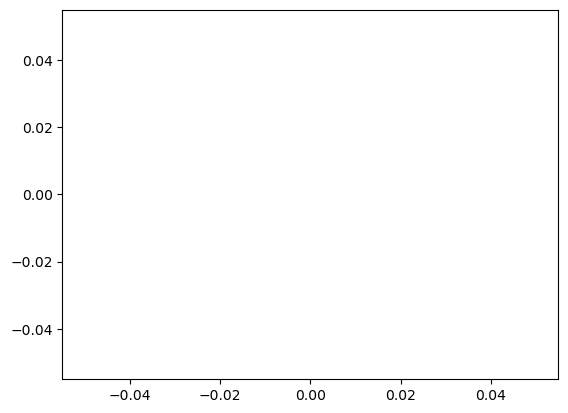

In [22]:
df["cashflow_usd"].plot()